In [ ]:
!pip install tensorflow

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [57]:
base_path = '/content/drive/My Drive/rockpaperscissors'

In [60]:
if not os.path.exists(base_path):
    raise FileNotFoundError(f"Data directory not found at: {base_path}")

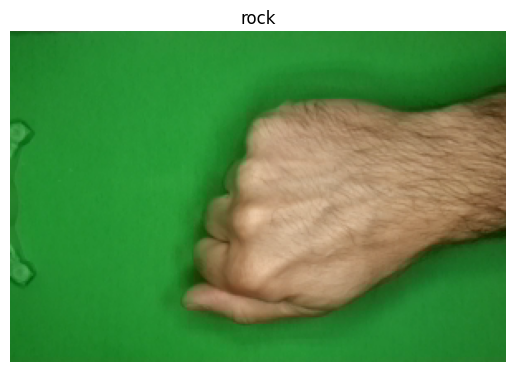

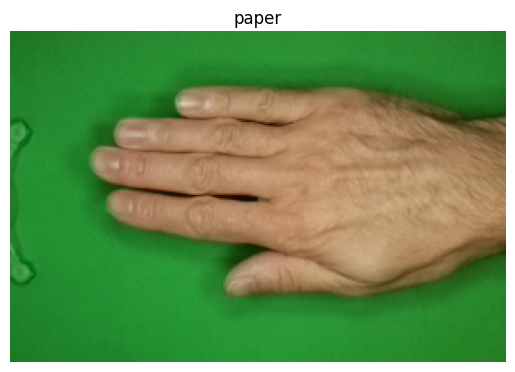

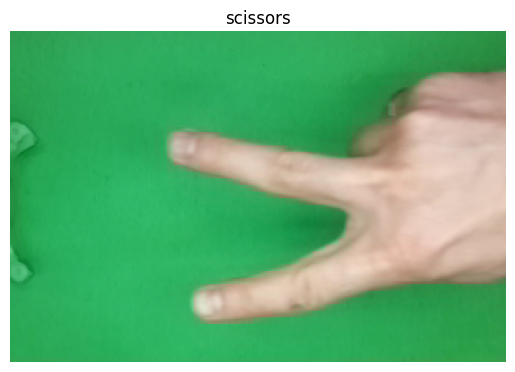

In [61]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

classes = ['rock', 'paper', 'scissors']
for cls in classes:
    img_path = f"/content/drive/My Drive/rockpaperscissors/{cls}"
    random_img = random.choice(os.listdir(img_path))
    img = mpimg.imread(os.path.join(img_path, random_img))
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    plt.show()

In [62]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    base_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    base_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # CRITICAL for proper evaluation
)

Found 1751 images belonging to 3 classes.
Found 437 images belonging to 3 classes.


In [63]:
print("✅ Classes found:", train_data.class_indices)
print("✅ Training samples:", train_data.samples)
print("✅ Validation samples:", val_data.samples)


✅ Classes found: {'paper': 0, 'rock': 1, 'scissors': 2}
✅ Training samples: 1751
✅ Validation samples: 437


In [64]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

In [65]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

In [66]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

initial_history = model.fit(train_data, validation_data=val_data, epochs=5)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5622 - loss: 0.9739 - val_accuracy: 0.9519 - val_loss: 0.2533
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9228 - loss: 0.2830 - val_accuracy: 0.9703 - val_loss: 0.1372
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9614 - loss: 0.1565 - val_accuracy: 0.9725 - val_loss: 0.0937
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9644 - loss: 0.1283 - val_accuracy: 0.9748 - val_loss: 0.0806
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.9744 - loss: 0.1043 - val_accuracy: 0.9771 - val_loss: 0.0699


In [70]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

fine_tune_history = model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.7637 - loss: 0.5109 - val_accuracy: 0.9657 - val_loss: 0.0871
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.9685 - loss: 0.1315 - val_accuracy: 0.9703 - val_loss: 0.0806
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.9790 - loss: 0.0955 - val_accuracy: 0.9725 - val_loss: 0.0678
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.9850 - loss: 0.0766 - val_accuracy: 0.9611 - val_loss: 0.0947
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.9785 - loss: 0.0583 - val_accuracy: 0.9703 - val_loss: 0.0767
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.9893 - loss: 0.0491 - val_accuracy: 0.9725 - val_loss: 0.0841
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.9902 - loss: 0.0358 - val_accuracy: 0.9703 - val_loss: 0.0974
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.9878 - loss: 0.0372 - val_accuracy: 0.9748 - v

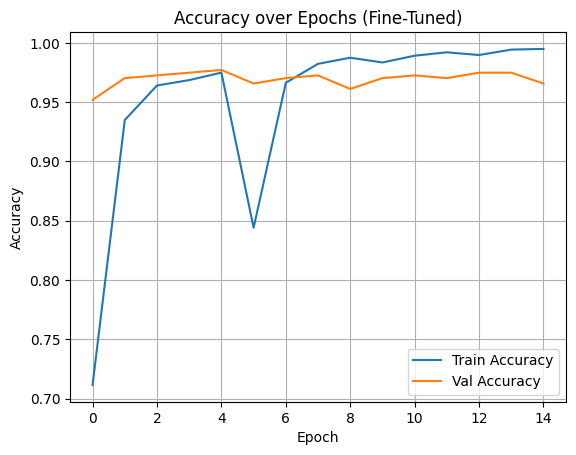

In [71]:
import matplotlib.pyplot as plt

# Combine histories
acc = initial_history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = initial_history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title("Accuracy over Epochs (Fine-Tuned)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [72]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [73]:
from sklearn.metrics import classification_report
import numpy as np

val_data.reset()
y_pred = np.argmax(model.predict(val_data), axis=1)
y_true = val_data.classes
labels = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))


14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step
              precision    recall  f1-score   support

       paper       1.00      0.95      0.97       142
        rock       1.00      1.00      1.00       145
    scissors       0.96      1.00      0.98       150

    accuracy                           0.98       437
   macro avg       0.99      0.98      0.98       437
weighted avg       0.98      0.98      0.98       437



In [74]:
y_true = val_data.classes

In [75]:
class_labels = list(val_data.class_indices.keys())

In [76]:
print("📋 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

📋 Classification Report:

              precision    recall  f1-score   support

       paper       1.00      0.95      0.97       142
        rock       1.00      1.00      1.00       145
    scissors       0.96      1.00      0.98       150

    accuracy                           0.98       437
   macro avg       0.99      0.98      0.98       437
weighted avg       0.98      0.98      0.98       437



In [86]:
cm = confusion_matrix(y_true, y_pred)

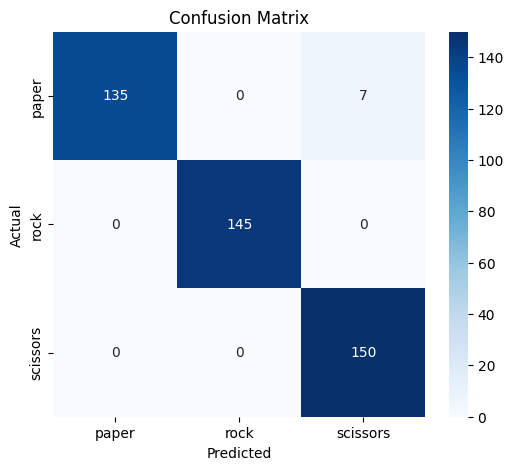

In [87]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [78]:
accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f"✅ Final Validation Accuracy: {accuracy:.2%}")

✅ Final Validation Accuracy: 98.40%


In [79]:
train_labels = train_data.classes
val_labels = val_data.classes

In [80]:
class_names = list(train_data.class_indices.keys())

In [81]:
unique_train, counts_train = np.unique(train_labels, return_counts=True)
print("📊 Training Class Distribution:")
for label, count in zip(unique_train, counts_train):
    print(f"{class_names[label]}: {count}")

📊 Training Class Distribution:
paper: 570
rock: 581
scissors: 600


In [82]:
unique_val, counts_val = np.unique(val_labels, return_counts=True)
print("\n📊 Validation Class Distribution:")
for label, count in zip(unique_val, counts_val):
    print(f"{class_names[label]}: {count}")


📊 Validation Class Distribution:
paper: 142
rock: 145
scissors: 150


In [88]:
model.save("rps_mobilenetv2_final.keras")
print("✅ Model saved as rps_mobilenetv2_final.h5")

✅ Model saved as rps_mobilenetv2_final.h5
